In [1]:
import torch
from collections import OrderedDict
from net.skeletonclr import SkeletonCLR

# 1) Now pretrain=False → only encoder_q is built
model = SkeletonCLR(
    base_encoder='net.st_gcn.Model',
    pretrain=True,
    feature_dim=32,      # irrelevant here, but must match signature
    queue_size=32768,     # irrelevant
    # … same other kwargs (in_channels, hidden_channels, etc) …
    in_channels=3,
    hidden_channels=16,
    hidden_dim=256,
    num_class=60,         # now your downstream # of classes
    dropout=0.5,
    graph_args={'layout':'ntu-rgb+d','strategy':'spatial'},
    edge_importance_weighting=True
)

In [2]:
# 3.1 Load raw checkpoint
ckpt = torch.load('epoch300_model.pt', map_location='cpu')
state_dict = ckpt.get('state_dict', ckpt)

# 3.2 Strip any DataParallel prefixes
clean_sd = OrderedDict()
for k, v in state_dict.items():
    name = k.replace('module.', '')
    clean_sd[name] = v

# 3.3 Load into model (strict=False lets you skip mismatches, e.g. if queue was saved differently)
missing, unexpected = model.load_state_dict(clean_sd, strict=False)
print(f"Missing keys: {missing}")
print(f"Unexpected keys: {unexpected}")


Missing keys: []
Unexpected keys: []


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

SkeletonCLR(
  (encoder_q): Model(
    (data_bn): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (st_gcn_networks): ModuleList(
      (0): st_gcn(
        (gcn): ConvTemporalGraphical(
          (conv): Conv2d(3, 48, kernel_size=(1, 1), stride=(1, 1))
        )
        (tcn): Sequential(
          (0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU(inplace=True)
          (2): Conv2d(16, 16, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0))
          (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (4): Dropout(p=0, inplace=True)
        )
        (relu): ReLU(inplace=True)
      )
      (1-3): 3 x st_gcn(
        (gcn): ConvTemporalGraphical(
          (conv): Conv2d(16, 48, kernel_size=(1, 1), stride=(1, 1))
        )
        (tcn): Sequential(
          (0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (

In [4]:
model.encoder_q.edge_importance

ParameterList(
    (0): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (1): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (2): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (3): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (4): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (5): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (6): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (7): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (8): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
    (9): Parameter containing: [torch.float32 of size 3x25x25 (cuda:0)]
)

In [5]:
batch_size, C, T, V, M = 10, 3, 20, 25, 1
dummy_q = torch.randn(batch_size, C, T, V, M).cuda()
dummy_k = torch.randn(batch_size, C, T, V, M).cuda()

with torch.no_grad():
    logits, labels, features = model(dummy_q, dummy_k)

print("logits shape:", logits.shape)  
print("labels shape:", labels.shape)
print("features shape:", features.shape)

logits shape: torch.Size([10, 32769])
labels shape: torch.Size([10])
features shape: torch.Size([10, 2, 32])


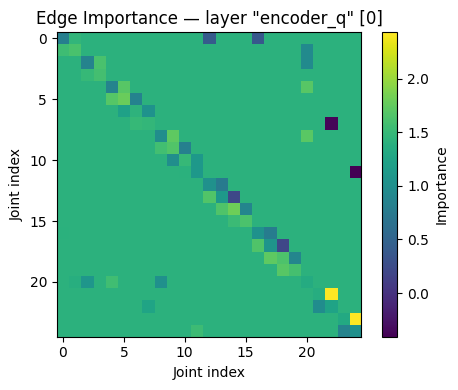

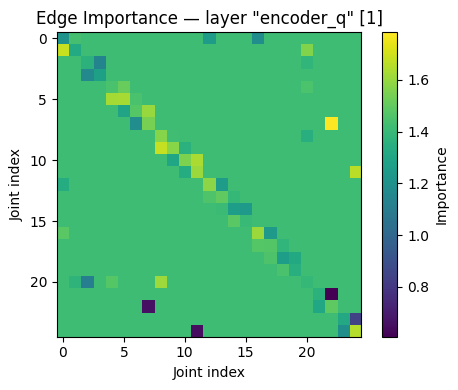

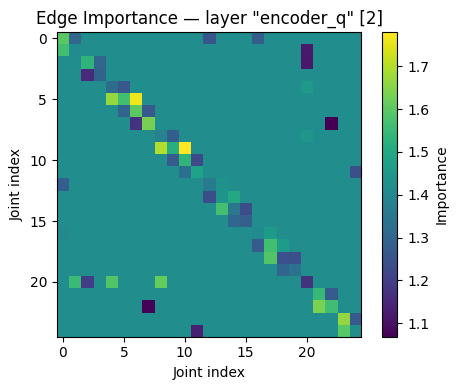

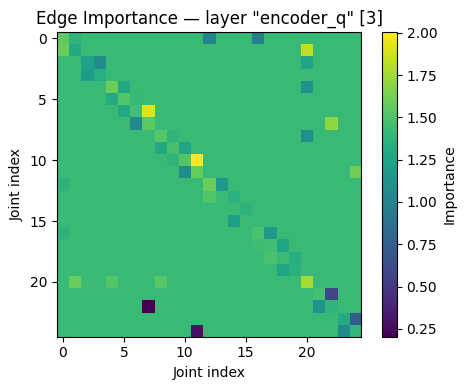

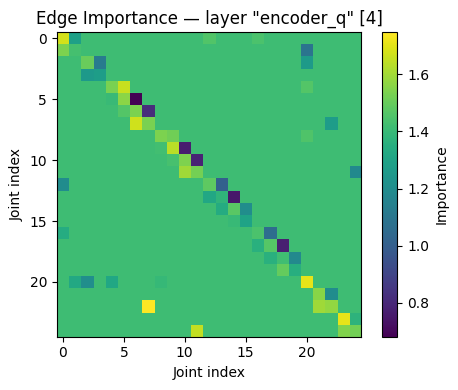

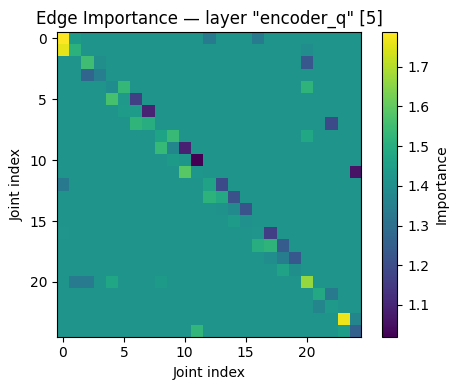

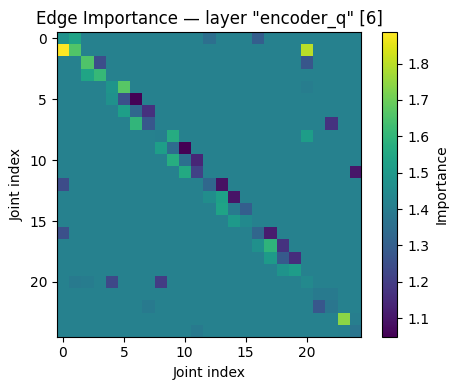

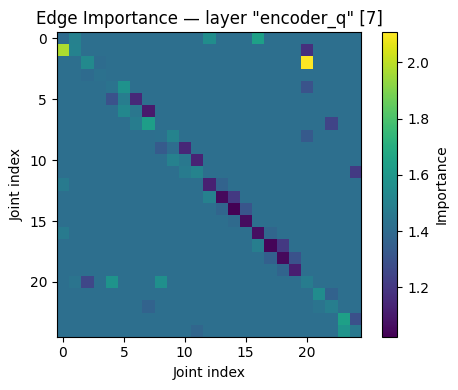

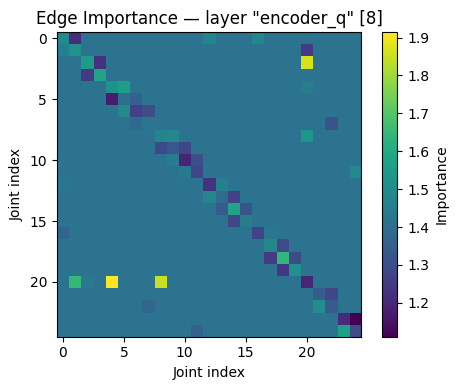

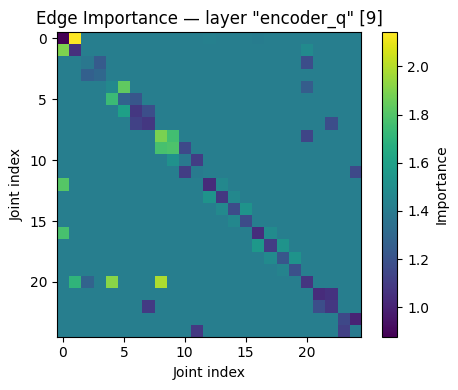

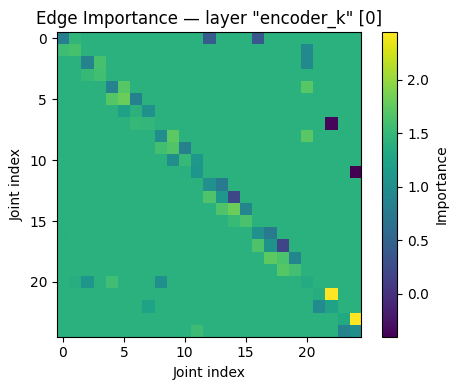

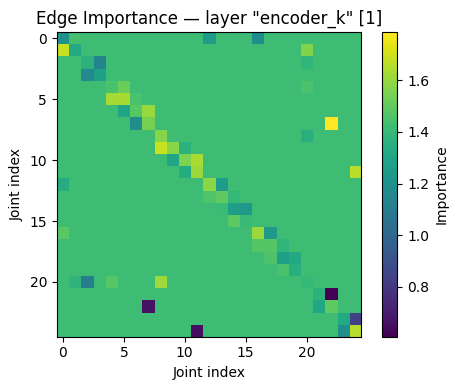

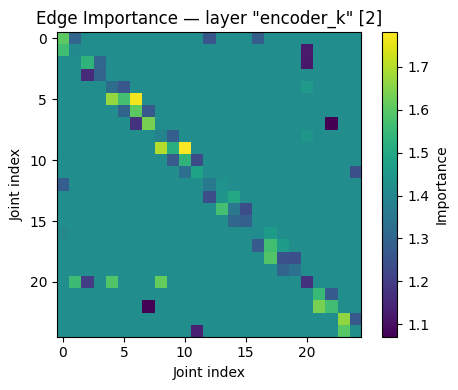

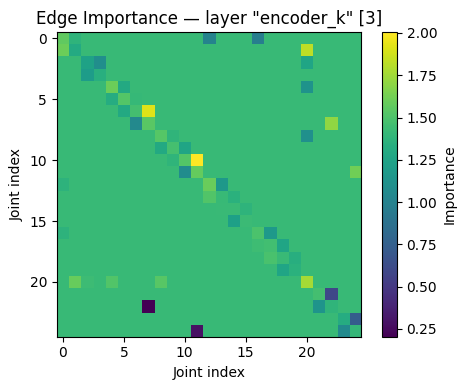

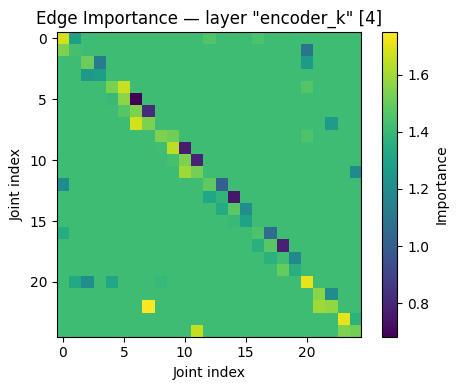

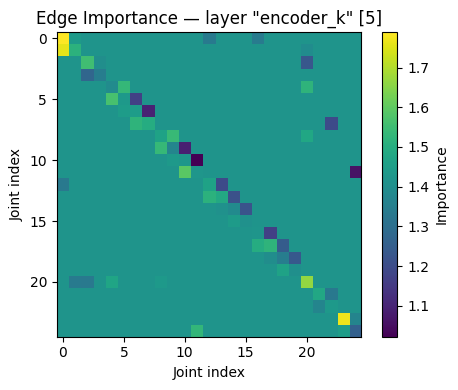

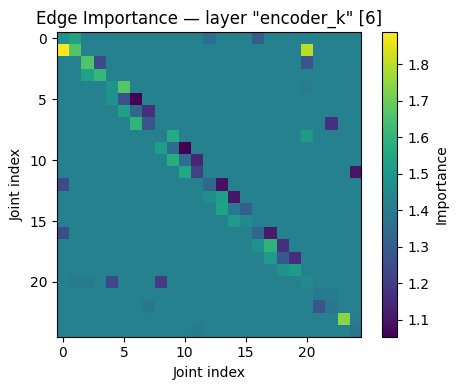

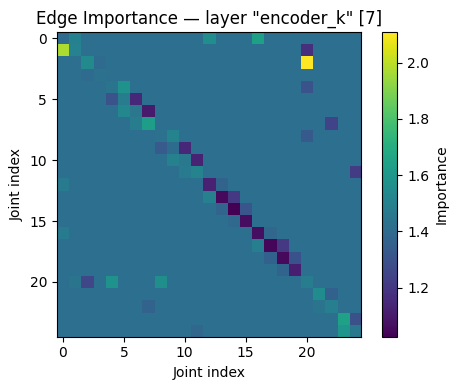

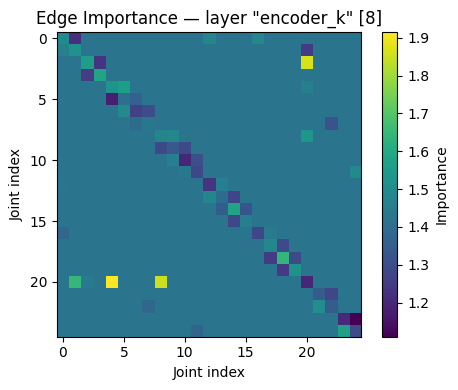

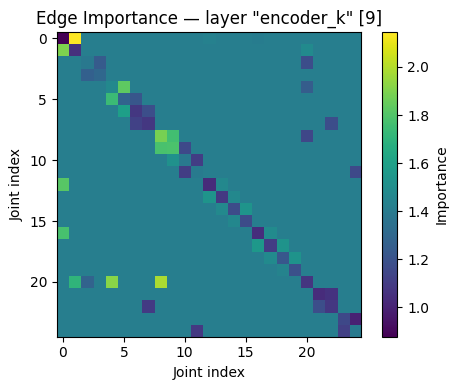

In [6]:
import torch
import matplotlib.pyplot as plt
from torch.nn import ParameterList


for name, module in model.named_modules():
    if hasattr(module, 'edge_importance'):
        importance_list = module.edge_importance

        for layer_idx, imp in enumerate(importance_list):
            mat = imp.detach().cpu().sum(dim=0).numpy()

            plt.figure(figsize=(5, 4))
            plt.imshow(mat, cmap='viridis')
            plt.title(f'Edge Importance — layer "{name}" [{layer_idx}]')
            plt.xlabel('Joint index')
            plt.ylabel('Joint index')
            plt.colorbar(label='Importance')
            plt.tight_layout()
            plt.show()

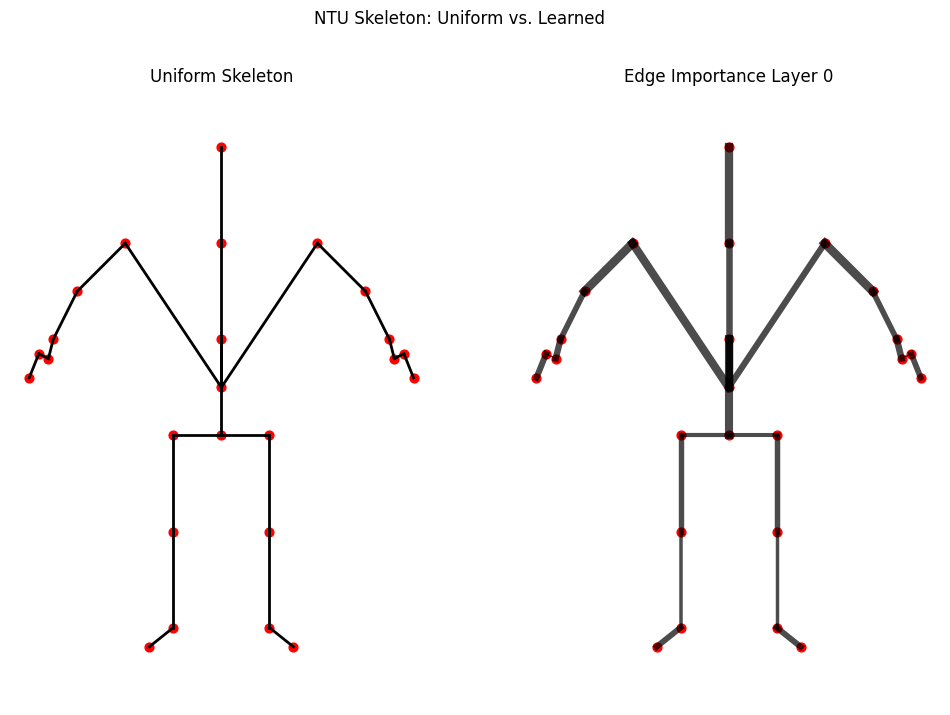

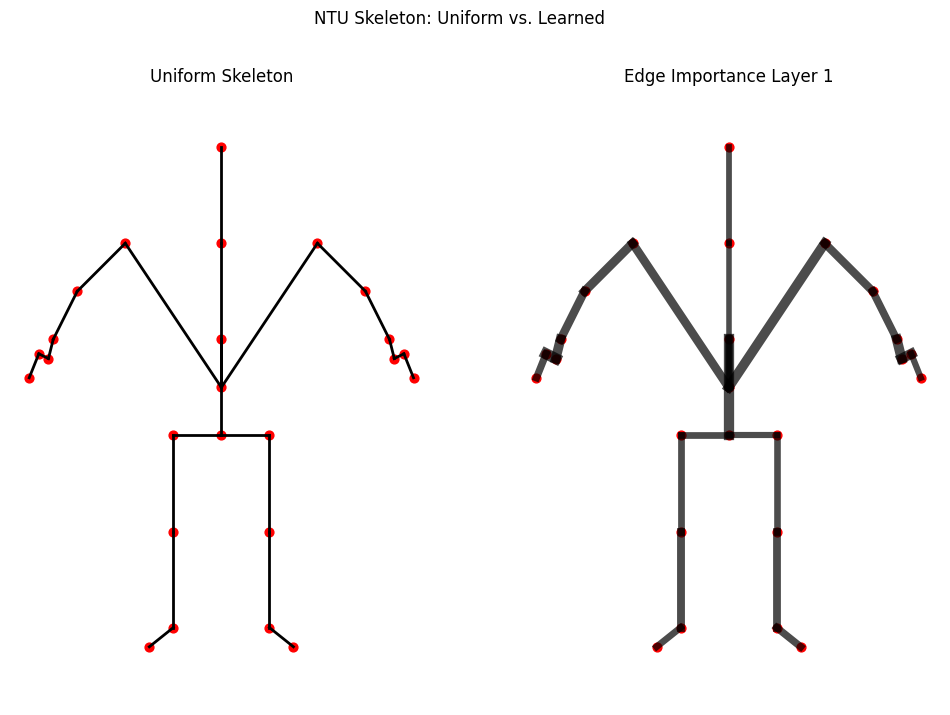

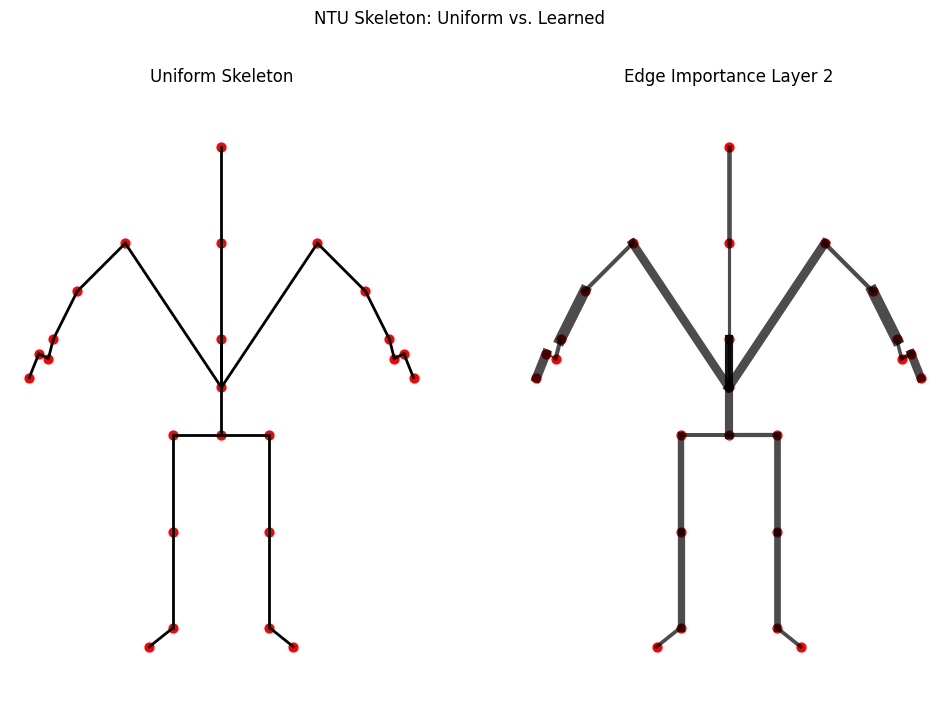

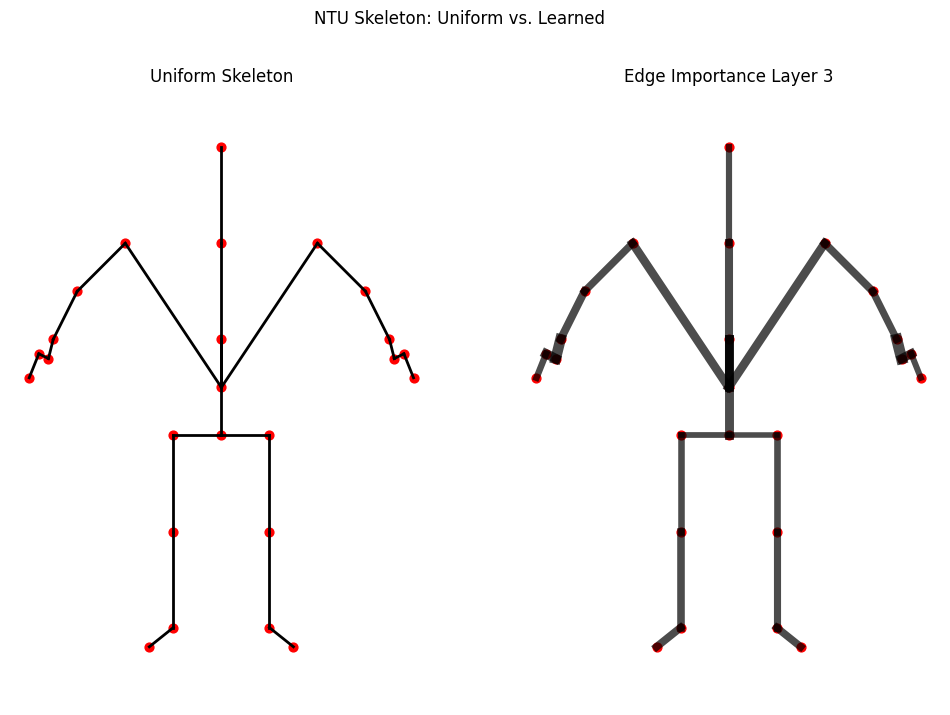

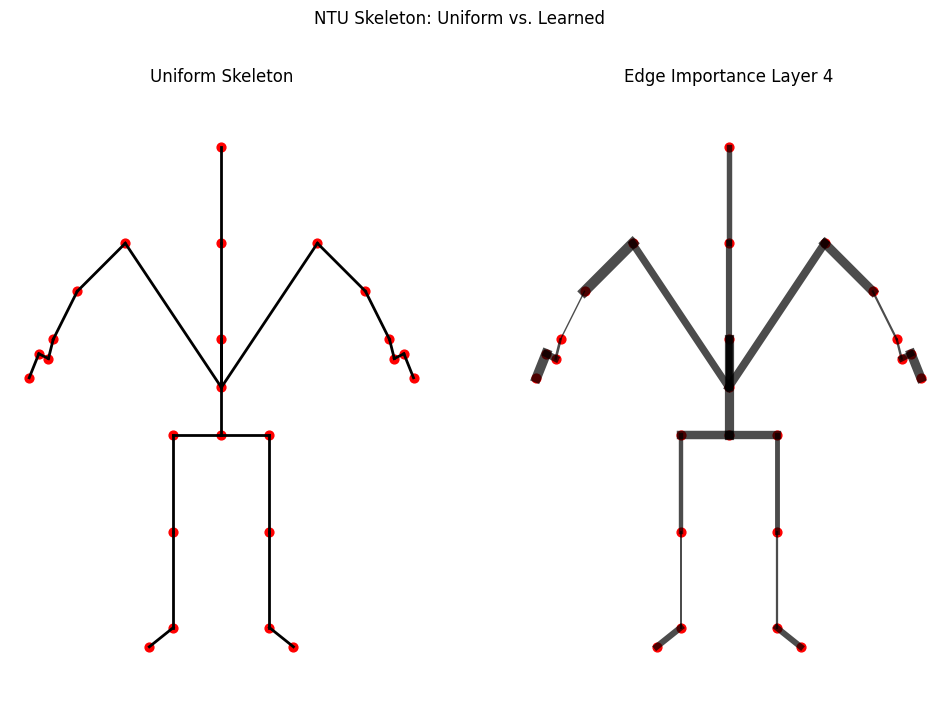

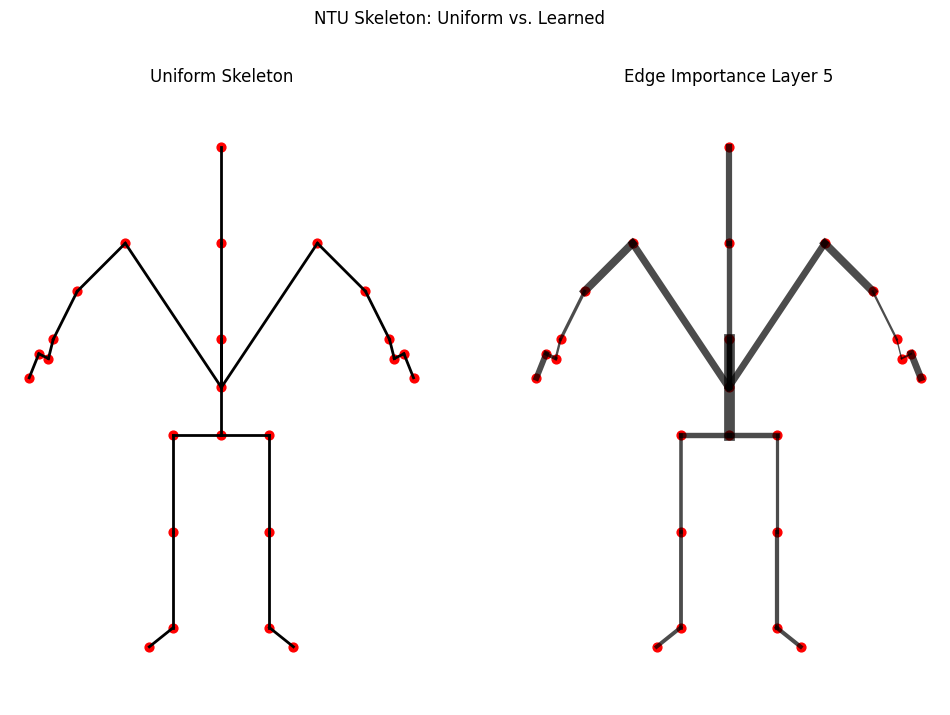

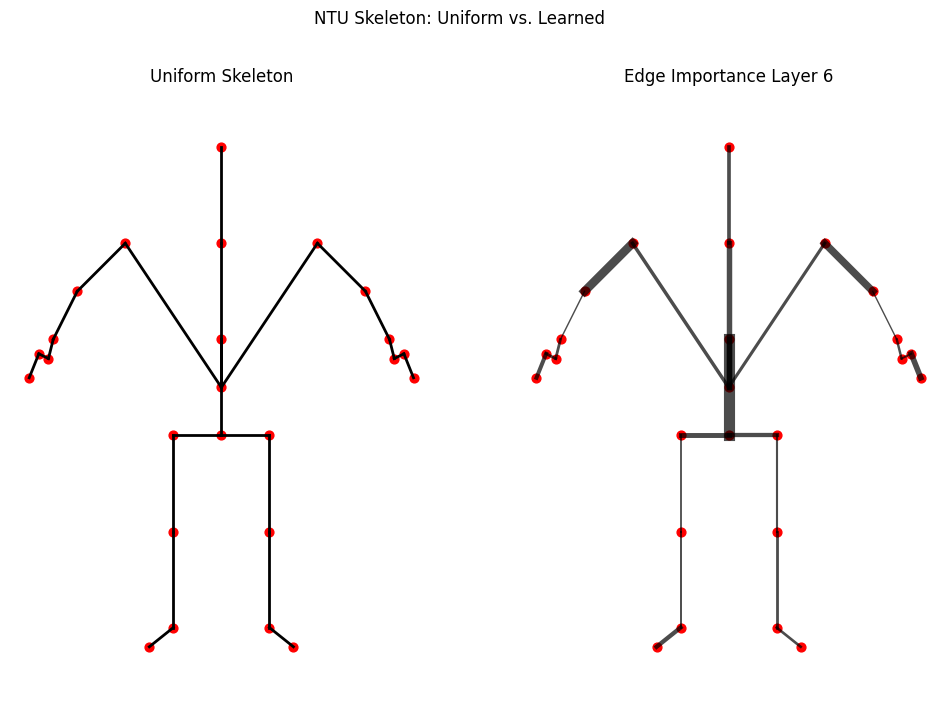

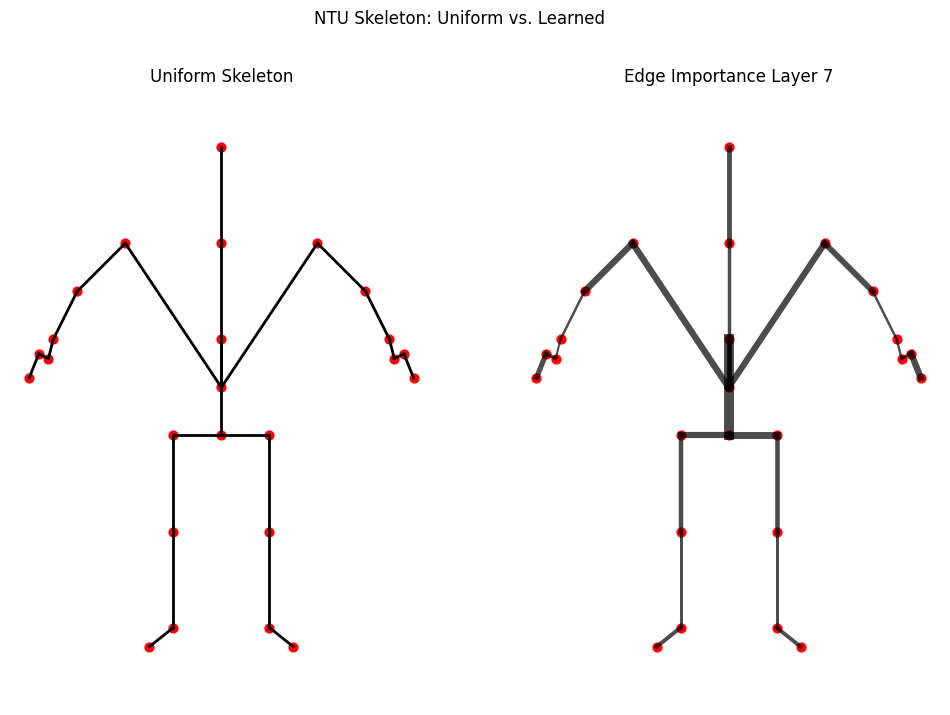

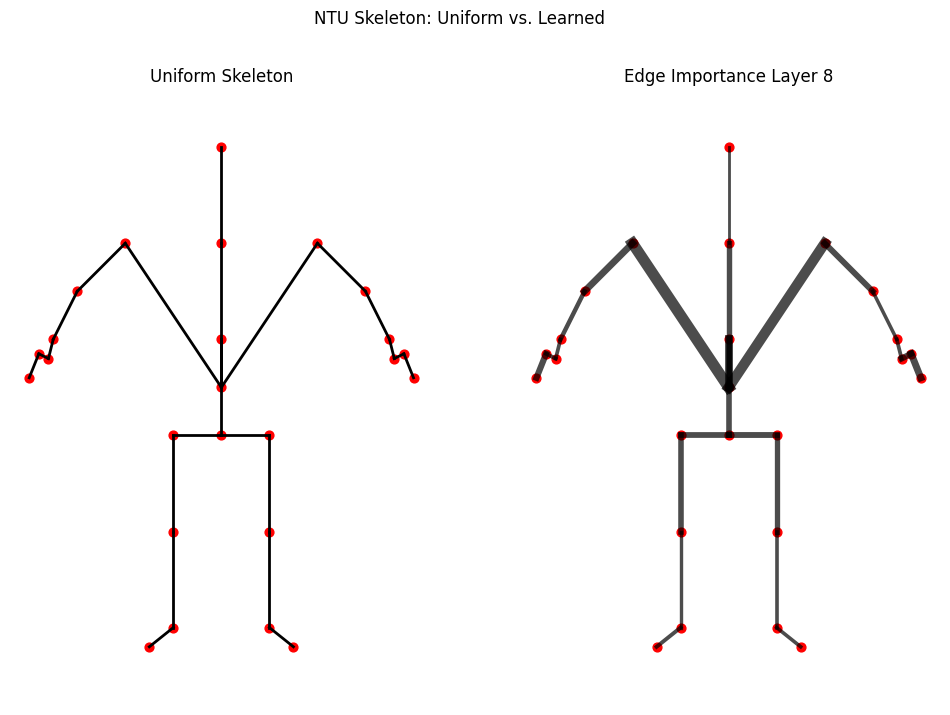

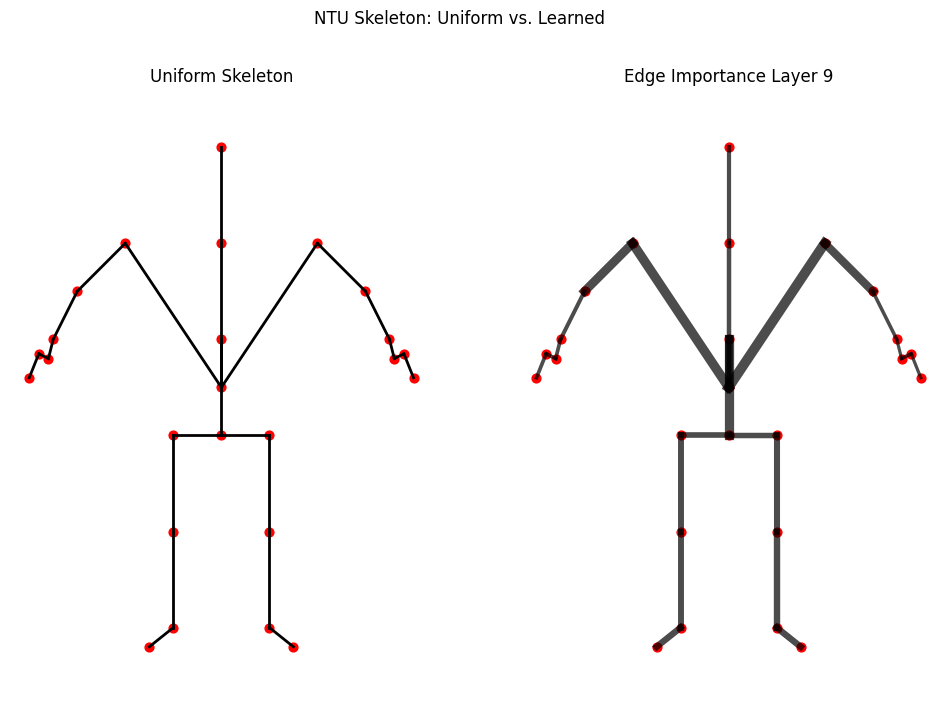

In [7]:
import numpy as np
import matplotlib.pyplot as plt

self_links = [(i, i) for i in range(25)]
neighbor_1base = [
    (1,2),(2,21),(3,21),(4,3),(5,21),(6,5),(7,6),(8,7),
    (9,21),(10,9),(11,10),(12,11),(13,1),(14,13),(15,14),
    (16,15),(17,1),(18,17),(19,18),(20,19),(22,23),(23,8),
    (24,25),(25,12)
]
neighbor = [(i-1, j-1) for (i,j) in neighbor_1base]
bones = self_links + neighbor

for layer_idx in range(10):
    LAYER_IDX = layer_idx
    imp_mat = model.encoder_q.edge_importance[LAYER_IDX] \
                   .sum(dim=0) \
                   .detach() \
                   .cpu() \
                   .numpy()
    w = (imp_mat - imp_mat.min()) / (imp_mat.max() - imp_mat.min() + 1e-6)
    max_lw = 8.0
    
    joint_coords = {
        1:  (0.0, 0.0),   2:  (0.0, 1.0),   3:  (0.0, 2.0),   4:  (0.0, 3.0),
        5:  (-1.0, 2.0),  6:  (-1.5,1.5),  7:  (-1.75,1.0), 8:  (-1.8,0.8),
        9:  (1.0, 2.0),   10: (1.5,1.5),   11: (1.75,1.0),  12: (1.8, 0.8),
        13: (-0.5,0.0),   14: (-0.5,-1.0), 15: (-0.5,-2.0), 16: (-0.75,-2.2),
        17: (0.5, 0.0),   18: (0.5,-1.0),  19: (0.5,-2.0),  20: (0.75,-2.2),
        21: (0.0, 0.5),   22: (-2.0,0.6),  23: (-1.9,0.85), 24: (2.0,0.6),
        25: (1.9, 0.85)
    }
    
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 8))
    
    for (i, j) in bones:
        if i == j: continue
        xi, yi = joint_coords[i+1]
        xj, yj = joint_coords[j+1]
        ax0.plot([xi, xj], [yi, yj], color='black', linewidth=2)
    ax0.scatter(*zip(*joint_coords.values()), c='red', s=40)
    ax0.axis('equal'); ax0.axis('off'); ax0.set_title('Uniform Skeleton')
    
    for (i, j) in bones:
        if i == j: continue
        xi, yi = joint_coords[i+1]
        xj, yj = joint_coords[j+1]
        lw = 1.0 + w[j, i] * (max_lw - 1.0)
        ax1.plot([xi, xj], [yi, yj], color='black', linewidth=lw, alpha=0.7)
    ax1.scatter(*zip(*joint_coords.values()), c='red', s=40)
    ax1.axis('equal'); ax1.axis('off'); ax1.set_title(f'Edge Importance Layer {LAYER_IDX}')
    
    plt.suptitle('NTU Skeleton: Uniform vs. Learned')
    plt.show()


## Dataset, Feature Extraction, Dendogrma

In [9]:
from feeder.ntu_feeder import Feeder_dual
from torch.utils.data import DataLoader

data_path = '/media/we/Data/Alvaro/datasets/NTU60_frame50/xview/train_position.npy'
label_path = '/media/we/Data/Alvaro/datasets/NTU-RGB-D/xview/train_label.pkl'

dataset = Feeder_dual(data_path, label_path, shear_amplitude=0.5, temperal_padding_ratio=6, mmap=True)

In [10]:
(x, _), y = dataset.__getitem__(0)

In [11]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, pin_memory=True, num_workers=24, drop_last=False)

In [15]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from feeder.ntu_feeder import Feeder_dual
from multiprocessing import cpu_count

data_path = '/media/we/Data/Alvaro/datasets/NTU60_frame50/xview/train_position.npy'
label_path = '/media/we/Data/Alvaro/datasets/NTU-RGB-D/xview/train_label.pkl'

dataset = Feeder_dual(data_path, label_path, shear_amplitude=0.5, temperal_padding_ratio=6, mmap=True)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, pin_memory=True,
                        num_workers=min(24, cpu_count()), drop_last=False)

model.eval()

features_list = []
labels_list = []

with torch.no_grad():
    for batch in dataloader:
        (x, _), labels = batch
        data = x
        data = data.float().cuda()

        feats = model.encoder_q(data)          
        feats = feats.cpu().numpy()

        features_list.append(feats)
        if labels is not None:
            labels_list.append(labels.numpy())

features = np.concatenate(features_list, axis=0)
np.save('ntu_xview_features.npy', features)

if labels_list:
    labels_all = np.concatenate(labels_list, axis=0)
    np.save('ntu_xview_labels.npy', labels_all)



In [17]:
features.shape

(37646, 32)

In [18]:
labels_all.shape

(37646,)

torch.Size([37646, 32])


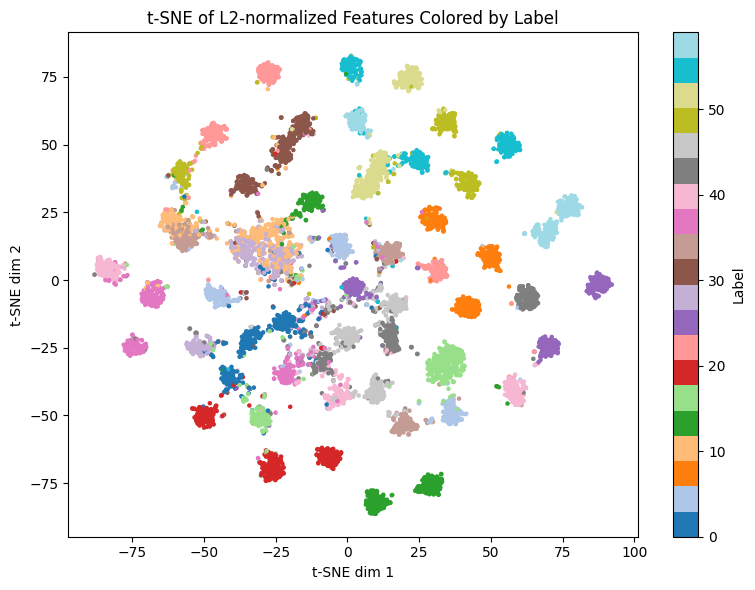

In [22]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

features_np = np.load('ntu_xview_features.npy')  # shape (N, D)
labels = np.load('ntu_xview_labels.npy')         # shape (N,)

features_tensor = torch.from_numpy(features_np).float()
print(features_tensor.shape)
features_norm = F.normalize(features_tensor, p=2, dim=1)
features_norm_np = features_norm.numpy()

subset_size = 10000
if features_norm_np.shape[0] > subset_size:
    rng = np.random.RandomState(0)
    idx = rng.choice(features_norm_np.shape[0], subset_size, replace=False)
    feats = features_norm_np[idx]
    labs = labels[idx]
else:
    feats = features_norm_np
    labs = labels

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
emb = tsne.fit_transform(feats)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(emb[:, 0], emb[:, 1], c=labs, cmap='tab20', s=5)
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.title('t-SNE of L2-normalized Features Colored by Label')
plt.colorbar(scatter, label='Label')
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

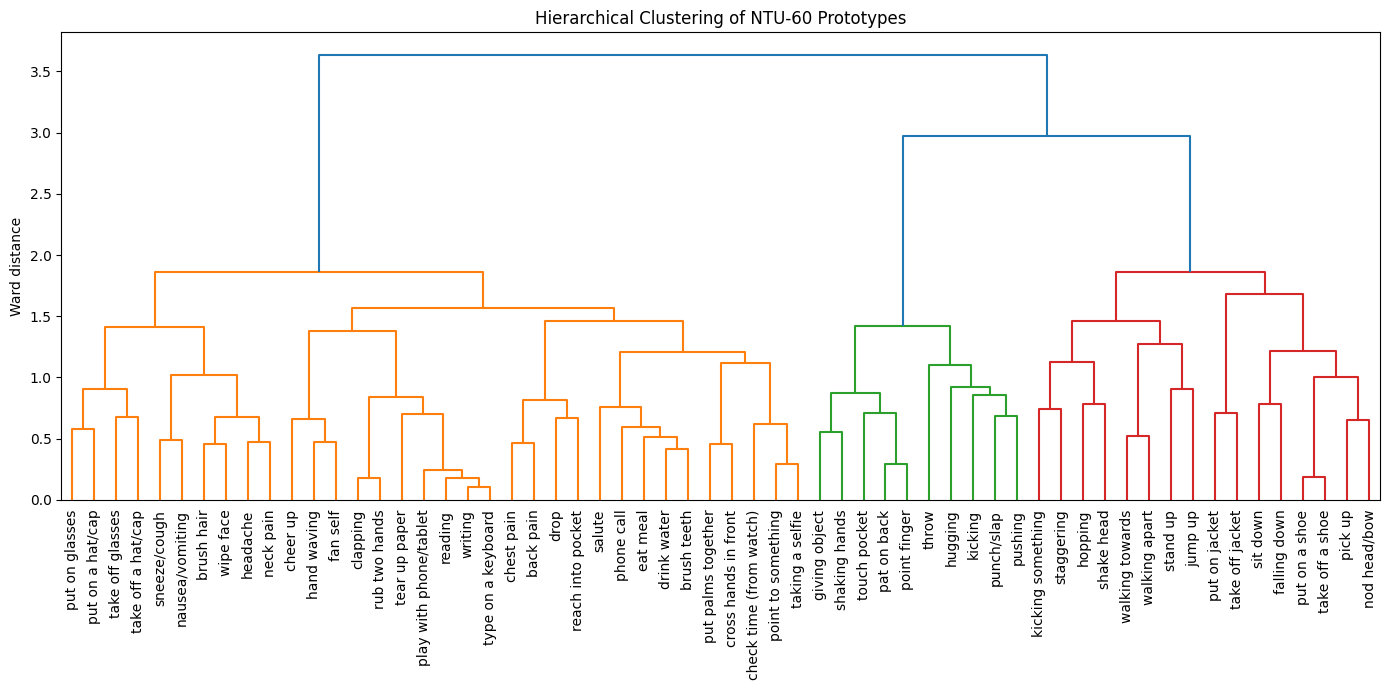

In [45]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

features = np.load('ntu_xview_features.npy')
labels   = np.load('ntu_xview_labels.npy')

unique_labels = np.unique(labels)
zero_based = unique_labels.min() == 0

if zero_based:
    mask = (labels >= 0) & (labels < 60)
else:
    mask = (labels >= 1) & (labels <= 60)
features = features[mask]
labels   = labels[mask]
unique_labels = np.unique(labels)

prototypes = np.vstack([
    features[labels == cls].mean(axis=0)
    for cls in unique_labels
])

norms = np.linalg.norm(prototypes, axis=1, keepdims=True) + 1e-12
prototypes_norm = prototypes / norms

action_names = [
 "drink water","eat meal","brush teeth","brush hair",
 "drop","pick up","throw","sit down",
 "stand up","clapping","reading","writing",
 "tear up paper","put on jacket","take off jacket","put on a shoe",
 "take off a shoe","put on glasses","take off glasses","put on a hat/cap",
 "take off a hat/cap","cheer up","hand waving","kicking something",
 "reach into pocket","hopping","jump up","phone call","play with phone/tablet",
 "type on a keyboard","point to something","taking a selfie","check time (from watch)",
 "rub two hands","nod head/bow","shake head","wipe face","salute",
 "put palms together","cross hands in front",
 "sneeze/cough","staggering","falling down","headache","chest pain",
 "back pain","neck pain","nausea/vomiting","fan self",
 "punch/slap","kicking","pushing","pat on back","point finger","hugging",
 "giving object","touch pocket","shaking hands","walking towards","walking apart"
]

labels_for_dendro = [
    action_names[int(cls) if zero_based else int(cls - 1)]
    for cls in unique_labels
]

Z = linkage(prototypes_norm, method='ward')
plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    labels=labels_for_dendro,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None,
    # truncate_mode='level',
    # p=5
)
plt.title('Hierarchical Clustering of NTU-60 Prototypes')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.show()

/home/we/.conda/envs/hypcrossclr/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


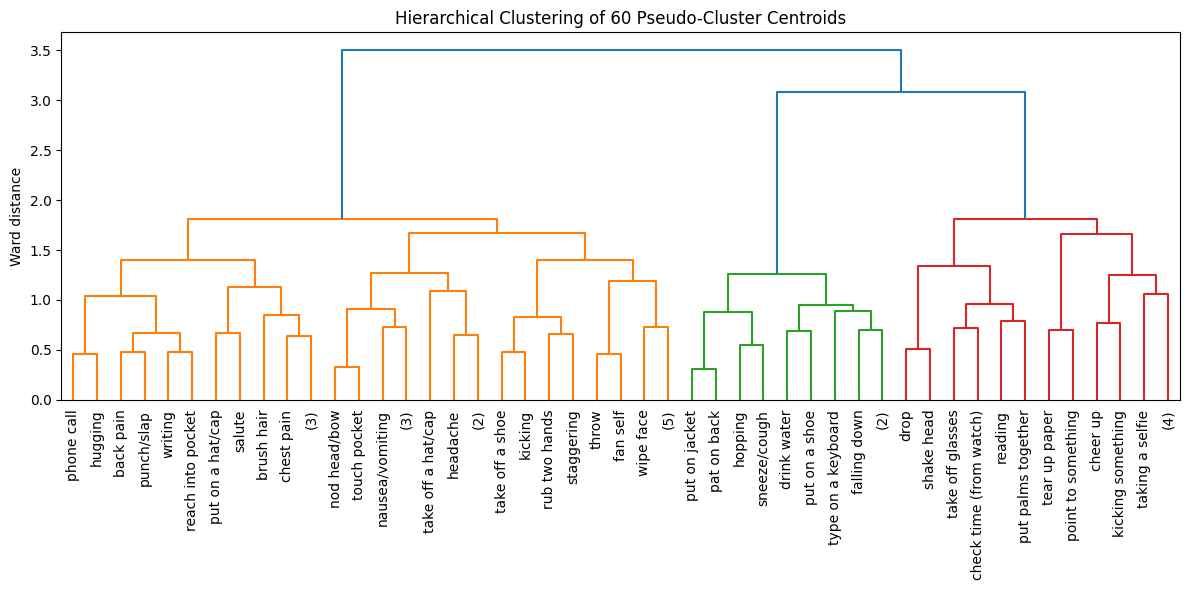

In [79]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

features = np.load('ntu_xview_features.npy')  
labels   = np.load('ntu_xview_labels.npy')  

ft = torch.from_numpy(features).float()
features_norm = F.normalize(ft, p=2, dim=1).numpy() 

Q = 60
kmeans = KMeans(n_clusters=Q, random_state=0).fit(features_norm)
pseudo_lbls = kmeans.labels_                       
centroids   = kmeans.cluster_centers_            

Z = linkage(centroids, method='ward')

action_names = [
 "drink water","eat meal","brush teeth","brush hair",
 "drop","pick up","throw","sit down",
 "stand up","clapping","reading","writing",
 "tear up paper","put on jacket","take off jacket","put on a shoe",
 "take off a shoe","put on glasses","take off glasses","put on a hat/cap",
 "take off a hat/cap","cheer up","hand waving","kicking something",
 "reach into pocket","hopping","jump up","phone call","play with phone/tablet",
 "type on a keyboard","point to something","taking a selfie","check time (from watch)",
 "rub two hands","nod head/bow","shake head","wipe face","salute",
 "put palms together","cross hands in front",
 "sneeze/cough","staggering","falling down","headache","chest pain",
 "back pain","neck pain","nausea/vomiting","fan self",
 "punch/slap","kicking","pushing","pat on back","point finger","hugging",
 "giving object","touch pocket","shaking hands","walking towards","walking apart"
]

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=action_names,
    truncate_mode='level',
    p=5,                   # show only the top 5 levels
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None
)
plt.title(f'Hierarchical Clustering of {Q} Pseudo-Cluster Centroids')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.show()

## AFTER THIS POINT IT IS EXPERIMENTAL, IT DOESN'T WORK :)

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.cluster import DBSCAN
from sklearn.mixture import BayesianGaussianMixture

# 1) Load & L2-normalize features
features = np.load('ntu_xview_features.npy')   # (N, D)
ft = torch.from_numpy(features).float()
Xn = F.normalize(ft, p=2, dim=1).numpy()      # (N, D)

# === Option A: DBSCAN (no K, tune eps & min_samples) ===
dbscan = DBSCAN(eps=0.5, min_samples=10, metric='euclidean')
pseudo_labels_db = dbscan.fit_predict(Xn)       # -1 = noise, 0... for clusters
print("DBSCAN found", len(set(pseudo_labels_db)) - (1 if -1 in pseudo_labels_db else 0), "clusters")

print(features.shape)

# === Option B: Dirichlet-Process GMM (scikit-learn DP-GMM) ===
dp_gmm = BayesianGaussianMixture(
    n_components=100,                                # upper bound on clusters
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=0.01,                 # smaller → fewer inferred clusters
    covariance_type='full',
    max_iter=1000,
    random_state=0
)
dp_gmm.fit(Xn)
pseudo_labels_dp = dp_gmm.predict(Xn)        # each sample gets a cluster ID
active = np.sum(dp_gmm.weights_ > 1e-4)
print("DP-GMM inferred", active, "active components")



In [93]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class DEC(nn.Module):
    def __init__(self, encoder, n_clusters, hidden_dim, alpha=1.0):
        super().__init__()
        self.encoder = encoder
        self.alpha   = alpha
        self.mu      = nn.Parameter(torch.randn(n_clusters, hidden_dim))

    def soft_assign(self, z):
        dist = torch.sum((z.unsqueeze(1) - self.mu.unsqueeze(0))**2, dim=2)  # [*, K]
        q    = (1 + dist/self.alpha).pow(-(self.alpha+1)/2)                  # [*, K]
        return (q.t() / q.sum(dim=1)).t()                                    # normalize → [*, K]

    def forward(self, x):
        z = self.encoder(x)           # x are precomputed embeddings
        z = F.normalize(z, dim=1)
        q = self.soft_assign(z)
        return z, q

features = np.load('ntu_xview_features.npy')   # (N, D)
X = torch.from_numpy(features).float()
X = F.normalize(X, dim=1)

dataset = TensorDataset(X)
loader  = DataLoader(dataset, batch_size=256, shuffle=True)

D = X.size(1)
K = 10
dec = DEC(nn.Identity(), n_clusters=K, hidden_dim=D)
opt = torch.optim.Adam(dec.parameters(), lr=1e-3)
dec_epochs = 100

all_z = X  # [N, D]
with torch.no_grad():
    all_q = dec.soft_assign(all_z)            # [N, K]
    num   = all_q**2 / all_q.sum(dim=0, keepdim=True)  # [N, K]
    den   = num.sum(dim=1, keepdim=True)               # [N, 1]
    all_p = (num / den).detach()                       # [N, K]

for epoch in range(dec_epochs):
    idx = 0
    for (batch_x,) in loader:
        B = batch_x.size(0)
        _, q_batch = dec(batch_x)           # [B, K]
        p_batch = all_p[idx:idx+B]          # [B, K]

        loss = F.kl_div(q_batch.log(), p_batch, reduction='batchmean')
        opt.zero_grad()
        loss.backward()
        opt.step()

        idx += B

    # Recompute all_p under no_grad
    with torch.no_grad():
        all_q = dec.soft_assign(all_z)
        num   = all_q**2 / all_q.sum(dim=0, keepdim=True)
        den   = num.sum(dim=1, keepdim=True)
        all_p = (num / den).detach()

with torch.no_grad():
    final_q      = dec.soft_assign(all_z)     # [N, K]
    pseudo_labels = final_q.argmax(dim=1).numpy()

np.save('dec_pseudo_labels.npy', pseudo_labels)


In [94]:
np.unique(pseudo_labels)

array([7])

In [95]:
unique_clusters, counts = np.unique(pseudo_labels, return_counts=True)

In [96]:
counts # only 1 cluster :(

array([37646])

In [97]:
features.shape

(37646, 32)